# Model Comparison: Custom CNN vs MobileNetV2 vs EfficientNetB0

## 1. Setup and Imports

In [1]:
import random
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Load Dataset and Explore Classes

In [3]:
dataset_path = "/content/drive/MyDrive/brain-tumor-mri-dataset"
data_dir_pathlib = pathlib.Path(dataset_path)
print("Classes:", [item.name for item in data_dir_pathlib.iterdir() if item.is_dir()])

Classes: ['meningioma', 'pituitary', 'glioma', 'notumor']


In [4]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Get class names and map them to integer labels
class_names = sorted([item.name for item in data_dir_pathlib.iterdir() if item.is_dir()])
class_to_label = {name: i for i, name in enumerate(class_names)}

# Load image paths and labels
all_image_paths = []
all_image_labels = []

for class_name in class_names:
    class_dir = data_dir_pathlib / class_name
    for image_path in class_dir.iterdir():
        all_image_paths.append(str(image_path))
        all_image_labels.append(class_to_label[class_name])

all_image_paths = np.array(all_image_paths)
all_image_labels = np.array(all_image_labels)

print(f"Total images: {len(all_image_paths)}")
print(f"Class names: {class_names}")

Total images: 7156
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 4. Recreate the Test Split

In [5]:
from sklearn.model_selection import train_test_split

# Split into training + temporary (validation + test)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_image_labels, test_size=0.3, stratify=all_image_labels, random_state=SEED
)

# Split temporary into validation and test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=SEED
)

print(f"Train: {len(train_paths)}  Val: {len(val_paths)}  Test: {len(test_paths)}")

Train: 5009  Val: 1073  Test: 1074


## 5. Build the Test Dataset

In [6]:
def load_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMAGE_SIZE)
    return image, label

def make_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(load_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    return ds


test_dataset = make_dataset(test_paths, test_labels)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

# Ground-truth labels for the test set, used by every model's evaluation below
y_true = np.concatenate([labels.numpy() for _, labels in test_dataset])

## 6. Load the Three Trained Models


In [7]:
CUSTOM_CNN_PATH = "/content/drive/MyDrive/cnn_model.keras"
MOBILENET_PATH = "/content/drive/MyDrive/final_mobilenet_model.keras"
EFFICIENTNET_PATH = "/content/drive/MyDrive/final_efficientnet_model.keras"

# Custom CNN uses a built-in Rescaling(1./255) layer -- no custom_objects needed.
custom_cnn_model = tf.keras.models.load_model(CUSTOM_CNN_PATH)

# MobileNetV2's saved Lambda layer is named "preprocess_input" and really does
# need mobilenet_v2's own preprocess_input (x / 127.5 - 1.0).
custom_objects_mobilenet = {
    "preprocess_input": tf.keras.applications.mobilenet_v2.preprocess_input
}
mobilenet_model = tf.keras.models.load_model(
    MOBILENET_PATH, custom_objects=custom_objects_mobilenet
)

# EfficientNetB0's saved Lambda layer is ALSO named "preprocess_input", but it
# must resolve to efficientnet's own (near pass-through) preprocess_input --
# loaded separately so the two don't collide.
custom_objects_efficientnet = {
    "preprocess_input": tf.keras.applications.efficientnet.preprocess_input
}
efficientnet_model = tf.keras.models.load_model(
    EFFICIENTNET_PATH, custom_objects=custom_objects_efficientnet
)

models = {
    "Custom CNN": custom_cnn_model,
    "MobileNetV2": mobilenet_model,
    "EfficientNetB0": efficientnet_model,
}

print("Loaded models:", list(models.keys()))

Loaded models: ['Custom CNN', 'MobileNetV2', 'EfficientNetB0']


## Verify Each Model's Preprocessing Layer



In [8]:
sample_batch = next(iter(test_dataset))[0][:1]  # one raw [0,255] image

for name, model in models.items():
    # first layer after any data augmentation/rescaling wrapper is the preprocessing step
    preprocessed = model.layers[0](sample_batch) if len(model.layers) else sample_batch
    print(f"{name:15s} raw min/max: {sample_batch.numpy().min():.1f}/{sample_batch.numpy().max():.1f}"
          f"   after first layer min/max: {preprocessed.numpy().min():.2f}/{preprocessed.numpy().max():.2f}")

Custom CNN      raw min/max: 0.0/247.0   after first layer min/max: 0.00/0.97
MobileNetV2     raw min/max: 0.0/247.0   after first layer min/max: 0.00/226.05
EfficientNetB0  raw min/max: 0.0/247.0   after first layer min/max: 0.00/235.03


## 7. Evaluate Each Model on the Test Set

In [9]:
results = {}

for name, model in models.items():
    loss, accuracy = model.evaluate(test_dataset, verbose=0)
    results[name] = {"Test Loss": loss, "Test Accuracy": accuracy}
    print(f"{name:15s} -> Test Loss: {loss:.4f} | Test Accuracy: {accuracy:.4f}")

Custom CNN      -> Test Loss: 0.7276 | Test Accuracy: 0.7058
MobileNetV2     -> Test Loss: 0.3975 | Test Accuracy: 0.8389
EfficientNetB0  -> Test Loss: 0.3137 | Test Accuracy: 0.8780


## 8. Generate Predictions for Each Model

In [10]:
predictions = {}

for name, model in models.items():
    y_pred_probs = model.predict(test_dataset, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    predictions[name] = y_pred

## 9. Classification Reports

In [11]:
from sklearn.metrics import classification_report

for name, y_pred in predictions.items():
    print(f"\n{'=' * 25} {name} {'=' * 25}")
    print(classification_report(y_true, y_pred, target_names=class_names))


========================= Custom CNN =========================
              precision    recall  f1-score   support

      glioma       0.72      0.67      0.69       243
  meningioma       0.74      0.28      0.41       267
     notumor       0.77      0.92      0.84       300
   pituitary       0.63      0.91      0.75       264

    accuracy                           0.71      1074
   macro avg       0.71      0.70      0.67      1074
weighted avg       0.72      0.71      0.68      1074


========================= MobileNetV2 =========================
              precision    recall  f1-score   support

      glioma       0.91      0.75      0.82       243
  meningioma       0.78      0.67      0.72       267
     notumor       0.99      0.93      0.96       300
   pituitary       0.72      0.98      0.83       264

    accuracy                           0.84      1074
   macro avg       0.85      0.83      0.83      1074
weighted avg       0.85      0.84      0.84      1074




## 10. Confusion Matrices Side by Side

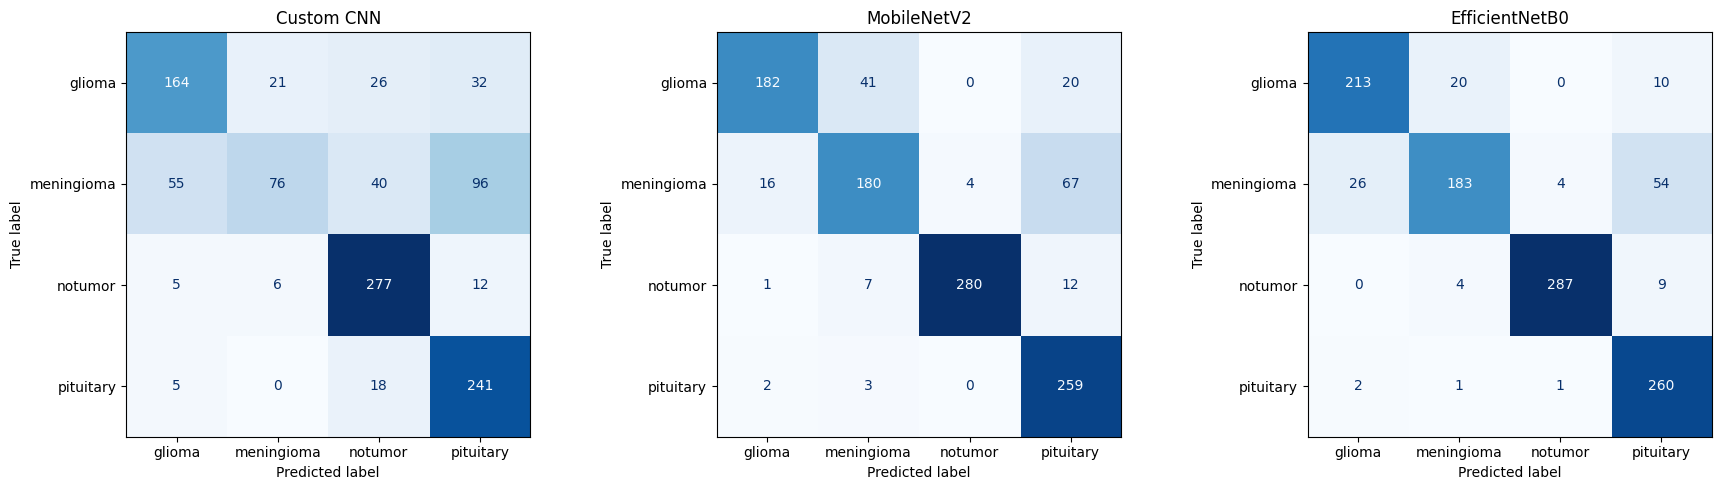

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, len(predictions), figsize=(6 * len(predictions), 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 11. Compare Precision, Recall, and F1-Score (Weighted Average)

In [13]:
from sklearn.metrics import precision_recall_fscore_support

for name, y_pred in predictions.items():
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted"
    )
    results[name]["Precision"] = precision
    results[name]["Recall"] = recall
    results[name]["F1-Score"] = f1

comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[["Test Accuracy", "Test Loss", "Precision", "Recall", "F1-Score"]]
comparison_df.round(4)

,Test Accuracy,Test Loss,Precision,Recall,F1-Score
Custom CNN,0.7058,0.7276,0.7153,0.7058,0.6772
MobileNetV2,0.8389,0.3975,0.8518,0.8389,0.8378
EfficientNetB0,0.8780,0.3137,0.8852,0.8780,0.8756


## 12. Visualize Model Comparison

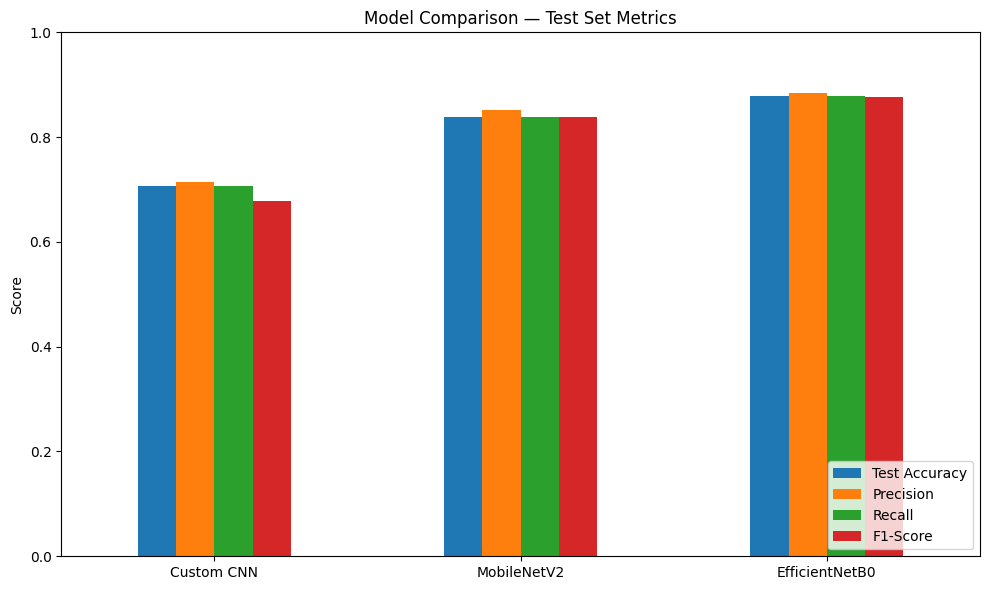

In [14]:
metrics_to_plot = ["Test Accuracy", "Precision", "Recall", "F1-Score"]

fig, ax = plt.subplots(figsize=(10, 6))
comparison_df[metrics_to_plot].plot(kind="bar", ax=ax)
ax.set_title("Model Comparison — Test Set Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

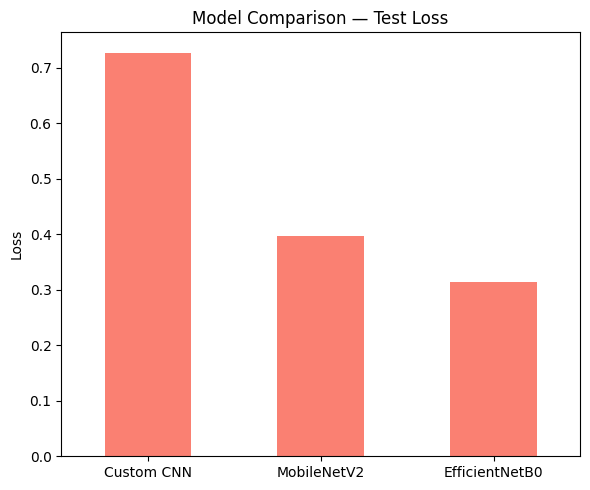

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
comparison_df["Test Loss"].plot(kind="bar", ax=ax, color="salmon")
ax.set_title("Model Comparison — Test Loss")
ax.set_ylabel("Loss")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. Summary

In [16]:
best_model_name = comparison_df["Test Accuracy"].idxmax()
print(f"Best performing model by test accuracy: {best_model_name}")
comparison_df.round(4)

Best performing model by test accuracy: EfficientNetB0


,Test Accuracy,Test Loss,Precision,Recall,F1-Score
Custom CNN,0.7058,0.7276,0.7153,0.7058,0.6772
MobileNetV2,0.8389,0.3975,0.8518,0.8389,0.8378
EfficientNetB0,0.8780,0.3137,0.8852,0.8780,0.8756
